In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
train_data = pd.read_csv(r"C:\Users\madus\OneDrive\Desktop\Railway Data\train_data.csv")
train_data.head()

,Transaction_ID,Date_of_Purchase,Time_of_Purchase,Purchase_Type,Payment_Method,Railcard,Ticket_Class,Ticket_Type,Price,Departure_Station,Arrival_Destination,Date_of_Journey,Departure_Time,Arrival_Time,Actual_Arrival_Time,Journey_Status,Reason_for_Delay,Refund_Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,9:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


In [7]:
train_data.isnull().sum()

Transaction_ID             0
Date_of_Purchase           0
Time_of_Purchase           0
Purchase_Type              0
Payment_Method             0
Railcard               20918
Ticket_Class               0
Ticket_Type                0
Price                      0
Departure_Station          0
Arrival_Destination        0
Date_of_Journey            0
Departure_Time             0
Arrival_Time               0
Actual_Arrival_Time     1880
Journey_Status             0
Reason_for_Delay       27481
Refund_Request             0
dtype: int64

In [9]:
train_data.dtypes

Transaction_ID         object
Date_of_Purchase       object
Time_of_Purchase       object
Purchase_Type          object
Payment_Method         object
Railcard               object
Ticket_Class           object
Ticket_Type            object
Price                   int64
Departure_Station      object
Arrival_Destination    object
Date_of_Journey        object
Departure_Time         object
Arrival_Time           object
Actual_Arrival_Time    object
Journey_Status         object
Reason_for_Delay       object
Refund_Request         object
dtype: object

In [11]:
train_data['Date_of_Journey'] = pd.to_datetime(train_data['Date_of_Journey'])
train_data['Departure_Time'] = pd.to_datetime(train_data['Departure_Time'], format = '%H:%M:%S', errors='coerce')

In [13]:
train_data['Hour'] = train_data['Departure_Time'].dt.hour
train_data['Day'] = train_data['Date_of_Journey'].dt.day_name()
train_data['Delay_Flag'] = (train_data['Journey_Status'] == 'Delayed').astype(int)

In [15]:
delay_rate = round(train_data['Delay_Flag'].mean(),4)
delay_rate

0.0724

In [17]:
trips_by_hour = train_data.groupby('Hour').size()
trips_by_hour

Hour
0      853
1      644
2      942
3      543
4     1041
5      725
6     3112
7     2795
8     2179
9     1230
10     525
11    1143
12     773
13    1276
14     855
15    1220
16    2301
17    2888
18    3113
19     438
20    1058
21     570
22     788
23     641
dtype: int64

In [19]:
train_data.groupby('Hour')['Delay_Flag'].mean()

Hour
0     0.019930
1     0.021739
2     0.000000
3     0.230203
4     0.015370
5     0.051034
6     0.023779
7     0.005367
8     0.334098
9     0.179675
10    0.000000
11    0.262467
12    0.000000
13    0.000000
14    0.017544
15    0.117213
16    0.089526
17    0.131925
18    0.000000
19    0.000000
20    0.000000
21    0.000000
22    0.000000
23    0.000000
Name: Delay_Flag, dtype: float64

In [21]:
train_data.groupby('Departure_Station')['Price'].sum().sort_values(ascending = False).head(10)

Departure_Station
London Kings Cross       199650
Liverpool Lime Street    135274
London Euston            112045
London Paddington         83842
Manchester Piccadilly     75314
London St Pancras         62957
Birmingham New Street     38116
York                      19546
Reading                   10127
Oxford                     2859
Name: Price, dtype: int64

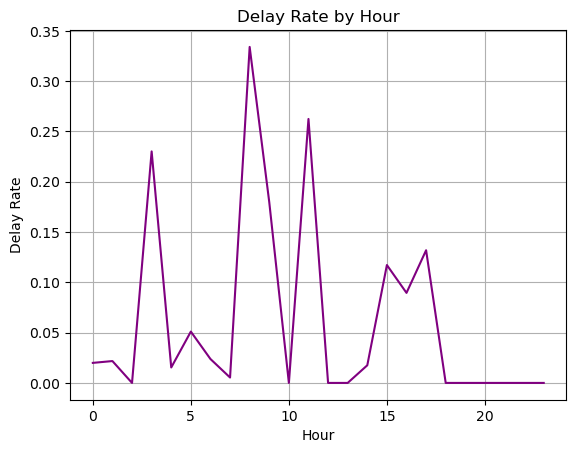

In [23]:
train_data.groupby('Hour')['Delay_Flag'].mean().sort_index().plot(color = 'purple')
plt.title("Delay Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Delay Rate")
plt.grid()
plt.show()

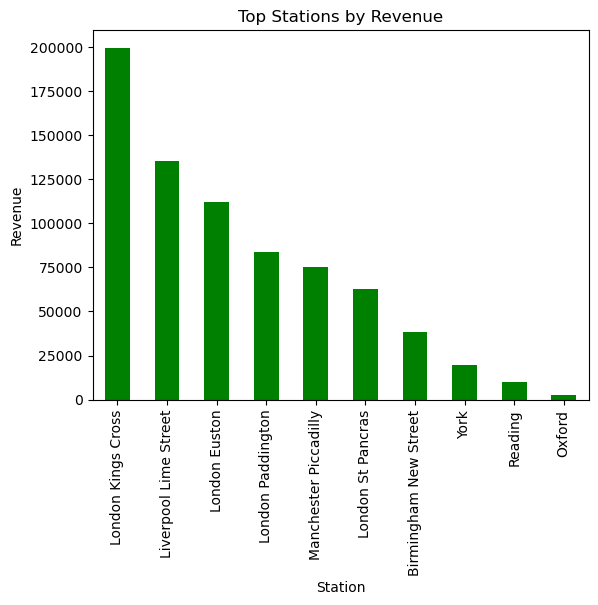

In [25]:
train_data.groupby('Departure_Station')['Price'].sum().sort_values(ascending = False).head(10).plot(kind = 'bar', color = 'green')
plt.title("Top Stations by Revenue")
plt.xlabel("Station")
plt.ylabel("Revenue")
plt.show()

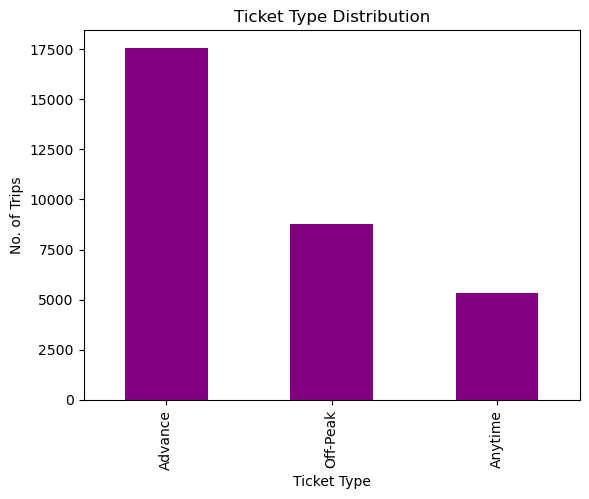

In [27]:
train_data.groupby('Ticket_Type')['Transaction_ID'].count().sort_values(ascending = False).plot(kind = 'bar', color = 'Purple')
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("No. of Trips")
plt.show()

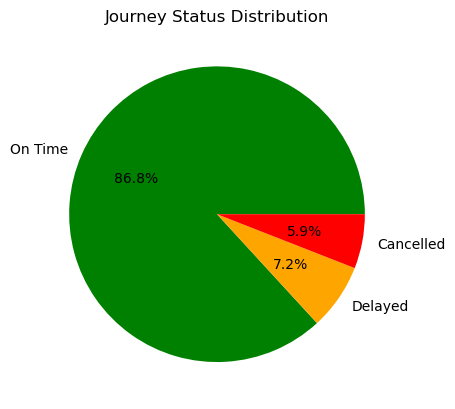

In [63]:
status_percentage = train_data['Journey_Status'].value_counts(normalize = True)*100
status_percentage.plot(kind = 'pie', autopct = '%1.1f%%', colors = ['green', 'orange', 'red'])
plt.title("Journey Status Distribution")
plt.ylabel("")
plt.show()